/tmp/ipykernel_31248/4105179920.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stim, sub in df.sort_values("rating_stimulus").groupby("rating_stimulus"):
/tmp/ipykernel_31248/4105179920.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Set1")


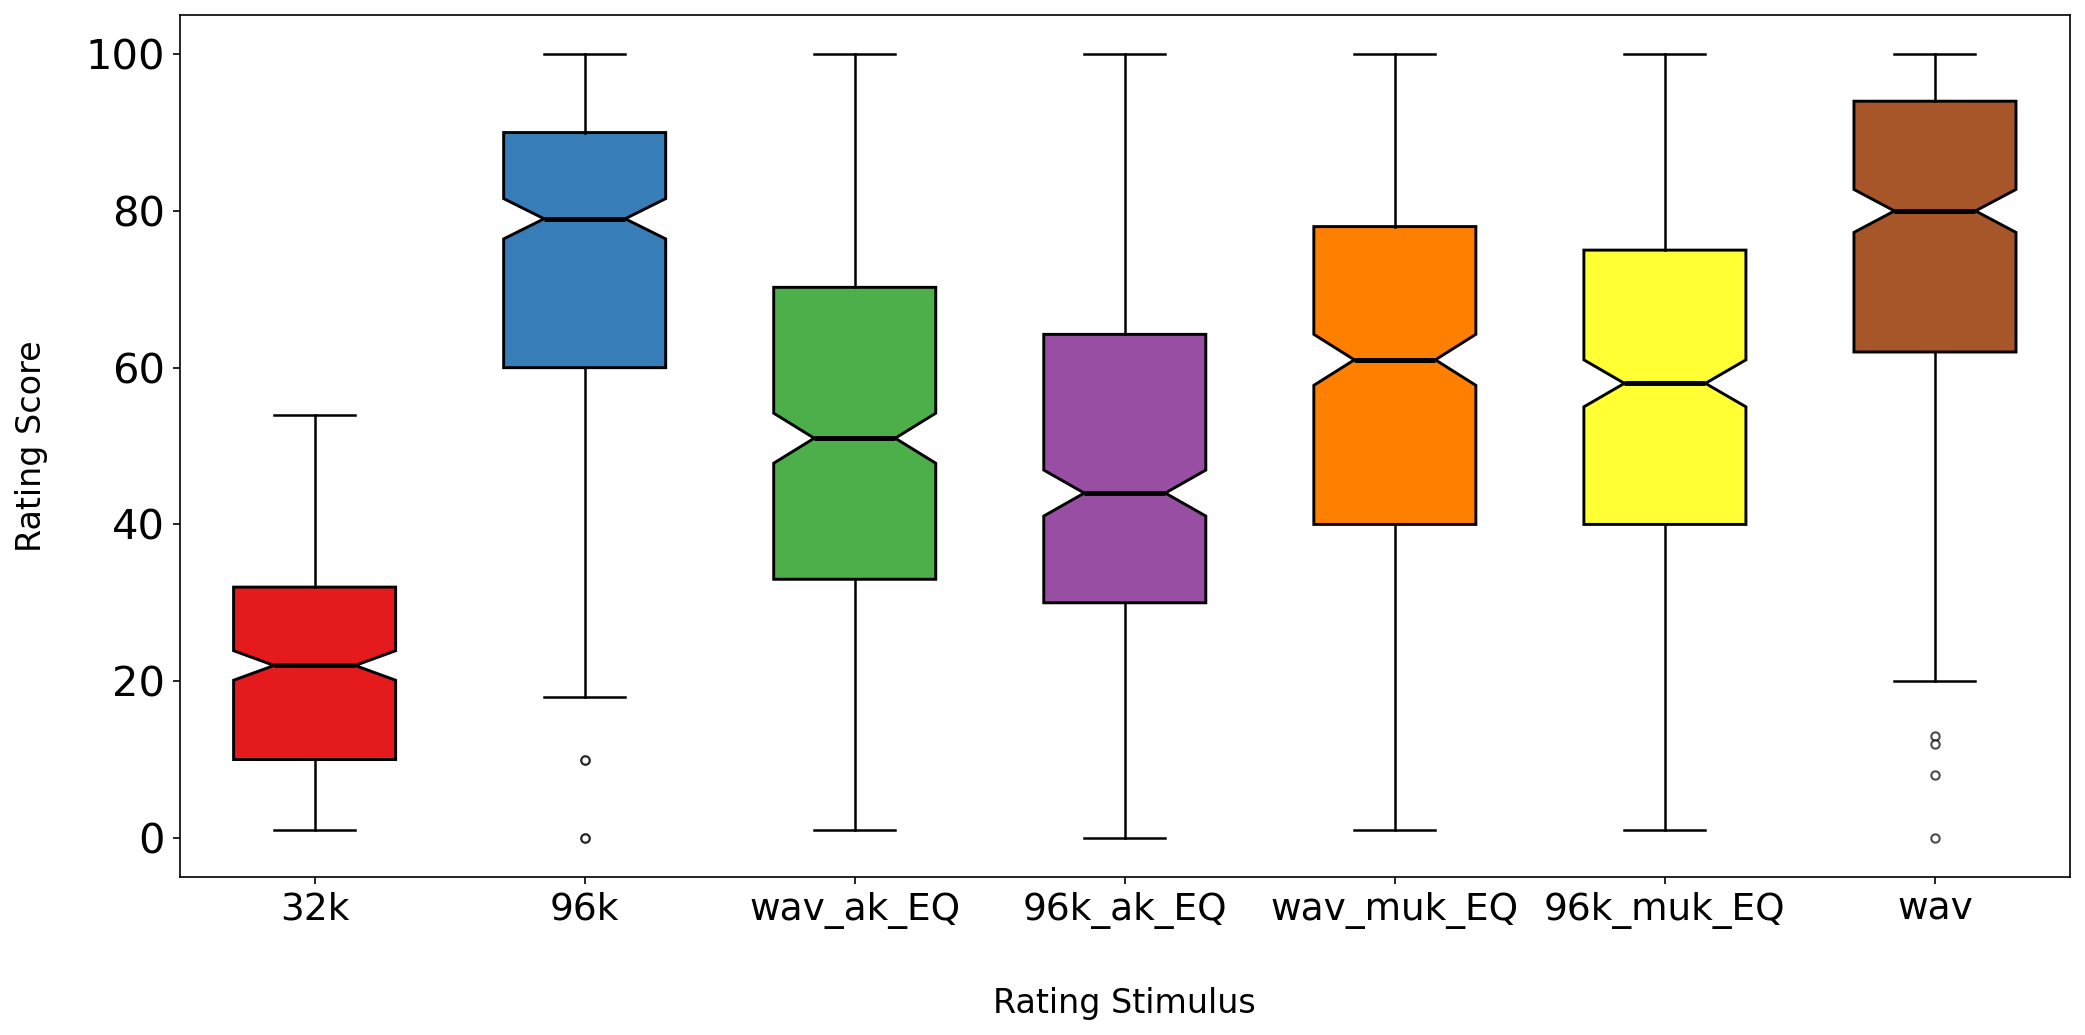

In [15]:

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from pathlib import Path


# --- Load data ---
df = pd.read_csv("df_rating_dataset.csv")
needed = {"rating_stimulus", "rating_score"}
if not needed.issubset(df.columns):
    raise ValueError(f"Missing columns: {needed - set(df.columns)}")

# Preserve category order
stim_order = pd.Categorical(df["rating_stimulus"],
                            categories=pd.unique(df["rating_stimulus"]),
                            ordered=True)
df = df.assign(rating_stimulus=stim_order)

# --- Group and labels ---
groups, labels = [], []
for stim, sub in df.sort_values("rating_stimulus").groupby("rating_stimulus"):
    labels.append(stim)
    groups.append(sub["rating_score"].to_numpy())

    cmap = cm.get_cmap("Set1")
    colors = [cmap(i % cmap.N) for i in range(len(labels))]

# --- Plot ---
plt.figure(figsize=(14, 7), dpi=150)

bp = plt.boxplot(
    groups,
    notch=True,
    patch_artist=True,
    showfliers=True,
    widths=0.6
)

# --- Style elements ---
for i, box in enumerate(bp["boxes"]):
    box.set(facecolor=colors[i], edgecolor="black", linewidth=1.4)
for whisker in bp["whiskers"]:
    whisker.set(color="black", linewidth=1.2)
for cap in bp["caps"]:
    cap.set(color="black", linewidth=1.2)
for median in bp["medians"]:
    median.set(color="black", linewidth=2.4)
for flier in bp["fliers"]:
    flier.set(marker="o", markersize=4, alpha=0.7,
              markeredgecolor="black", markerfacecolor="white")

# --- Fonts ---
plt.xticks(range(1, len(labels) + 1), labels, fontsize=18)
plt.yticks(fontsize=20)
plt.xlabel("Rating Stimulus", fontsize=16, labelpad=28)
plt.ylabel("Rating Score", fontsize=16, labelpad=18)
#plt.title("Boxplot of Rating Scores by Stimulus", fontsize=18, pad=15, weight="bold")

plt.tight_layout()

plt.show()

In [18]:
import pandas as pd

# Load your dataset
df = pd.read_csv("df_rating_dataset.csv")

# Group by 'rating_stimulus' and calculate mean and std
stats = (
    df.groupby("rating_stimulus")["rating_score"]
      .agg(["mean", "std", "count"])  # include count if you also want sample size
      .reset_index()
      .sort_values("mean", ascending=False)  # optional: sort by mean
)

# Print nicely
print(stats.to_string(index=False))

rating_stimulus      mean       std  count
            wav 75.982143 21.312031    336
            96k 74.458333 21.094770    336
     wav_muk_EQ 59.482143 23.441250    336
     96k_muk_EQ 57.148810 23.716268    336
      wav_ak_EQ 52.071429 24.516719    336
      96k_ak_EQ 47.821429 24.744141    336
            32k 22.324405 13.719323    336
